# A DATA-DRIVEN ANALYSIS OF RETENTION PATTERNS AND WORKFORCE CHALLENGES AMONG MIGRANT CARE WORKERS IN THE UK SOCIAL CARE SECTOR

# NOTEBOOK 1: Data Preparation and Initial Exploration

## Introduction

This notebook prepares and explores the three datasets used in this study: Skills for Care, Home Office Health and Care Worker visa statistics, and the Office for National Statistics (ONS). Data cleaning, validation, descriptive statistics, and initial visualisations are performed to produce analysis-ready datasets and provide an initial understanding of key workforce and migration trends.


### Data Cleaning and Preparation

The initial data cleaning was carried out in Microsoft Excel before the dataset was imported into Python for further analysis. Unnecessary rows and columns that were not relevant to the research objectives were removed, and the resulting dataset was saved as the cleaned dataset. This process is consistent with the data preparation procedures described in the methodology chapter of the report. Further analysis, transformation and validation of the cleaned data were subsequently undertaken in Python.

# Part I: Skills for Care Dataset

This section prepares and explores the Skills for Care dataset. The dataset provides national workforce indicators for the UK adult social care sector, including staffing levels, vacancies, turnover and workforce movement. Data cleaning is performed before an initial exploration of key workforce indicators.

## 1. Import Libraries

The required Python libraries are imported to support data manipulation, visualisation, and preprocessing. 

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

# Data visualisation
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Plot settings
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

## 2. Load the Dataset

The cleaned Skills for Care dataset is loaded into Python to begin the analysis. This step ensures that the dataset is successfully imported and ready for inspection, validation, and exploratory analysis.

In [2]:
## Loading Skills for care dataset
sfc = pd.read_excel("../02_Clean_Data/Skills_for_Care/Skills_for_Care_Cleaned_Dataset.xlsx")

sfc.head()

## 3. Inspect the Dataset

The dataset is inspected to verify its structure, dimensions, variable types, and completeness before analysis. This step helps identify any potential data quality issues and confirms that the cleaned dataset is suitable for subsequent descriptive and exploratory analysis.

### 3.1 Dataset Preview

The first five observations are displayed to verify that the dataset has been imported correctly and to obtain an initial view of its structure.

In [3]:
sfc.head()

,Period,Year,Tot_Posts,Filled_Posts,FTE_Filled_Posts,FTE_Ratio,Employees,Turnover_Rt,Leavers,Vacancy_Rt,Vacant_Posts,Starters_Rt,Starters
0,2016/17,2017,960000,895000,670000,0.747,810000,0.302,245000,0.072,63000,0.371,300000
1,2017/18,2018,965000,900000,675000,0.748,820000,0.331,270000,0.076,67000,0.398,325000
2,2018/19,2019,975000,905000,680000,0.750,830000,0.342,285000,0.078,71000,0.413,345000
3,2019/20,2020,975000,910000,695000,0.763,825000,0.350,290000,0.076,68000,0.401,330000
4,2020/21,2021,1005000,940000,715000,0.761,845000,0.318,270000,0.074,68000,0.367,310000


**Interpretation**

The preview confirms that the dataset has been successfully imported and that the variables are correctly structured for analysis.

### 3.2 Dataset Dimensions


In [4]:
print(f"Rows: {sfc.shape[0]}")
print(f"Columns: {sfc.shape[1]}")

Rows: 10
Columns: 13


**Interpretation**
The dataset dimensions indicate the number of observations and variables available for analysis.

## 3.3 Data Types and Completeness

In [5]:
sfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Period            10 non-null     object 
 1   Year              10 non-null     int64  
 2   Tot_Posts         10 non-null     int64  
 3   Filled_Posts      10 non-null     int64  
 4   FTE_Filled_Posts  10 non-null     int64  
 5   FTE_Ratio         10 non-null     float64
 6   Employees         10 non-null     int64  
 7   Turnover_Rt       10 non-null     float64
 8   Leavers           10 non-null     int64  
 9   Vacancy_Rt        10 non-null     float64
 10  Vacant_Posts      10 non-null     int64  
 11  Starters_Rt       10 non-null     float64
 12  Starters          10 non-null     int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 1.1+ KB


**Interpretation**:
The output confirms the data types of each variable and provides an overview of dataset completeness.

## 3.4 Missing Values

In [6]:
sfc.isnull().sum()

Period              0
Year                0
Tot_Posts           0
Filled_Posts        0
FTE_Filled_Posts    0
FTE_Ratio           0
Employees           0
Turnover_Rt         0
Leavers             0
Vacancy_Rt          0
Vacant_Posts        0
Starters_Rt         0
Starters            0
dtype: int64

**Interpretation**:
The missing value summary identifies whether additional preprocessing is required before analysis.

## 4. Descriptive Statistics

Descriptive statistics are generated to summarise the main characteristics of the workforce variables. This provides an overview of the central tendency, variability, and distribution of the data before further exploratory analysis.

# 4.1 Summary Statistics

In [7]:
# Summary statistics
sfc.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,10.0,2021.50,3.03,2017.00,2019.25,2021.50,2023.75,2026.00
Tot_Posts,10.0,1035000.00,70277.23,960000.00,975000.00,1017500.00,1095000.00,1135000.00
Filled_Posts,10.0,957500.00,65880.78,895000.00,906250.00,932500.00,1001250.00,1070000.00
FTE_Filled_Posts,10.0,735500.00,67431.03,670000.00,683750.00,707500.00,781250.00,850000.00
FTE_Ratio,10.0,0.77,0.02,0.75,0.75,0.76,0.78,0.80
Employees,10.0,862000.00,53343.75,810000.00,826250.00,837500.00,892500.00,955000.00
Turnover_Rt,10.0,0.31,0.03,0.25,0.28,0.32,0.33,0.35
Leavers,10.0,264400.00,18258.64,237000.00,248250.00,270000.00,275000.00,290000.00
Vacancy_Rt,10.0,0.08,0.02,0.07,0.07,0.08,0.09,0.11
Vacant_Posts,10.0,78300.00,15578.12,63000.00,68000.00,70500.00,86250.00,105000.00


In [8]:
sfc_summary = sfc.describe().T.round(2)
sfc_summary.to_csv(
    "../04_Output/Tables/SkillsForCare_Summary_Statistics.csv"
)
print("Skills for Care summary statistics exported.")

Skills for Care summary statistics exported.


**Interpretation**:
The descriptive statistics summarise the distribution of the numerical variables, including their average values, variability, and range. These measures provide an initial understanding of workforce characteristics and help identify variables with unusually high variation or potential outliers.

### 4.1.1 Workforce Indicator Boxplots

Boxplots are used to complement the descriptive statistics by visually presenting the distribution, median, quartiles, and potential variation of the workforce indicators.

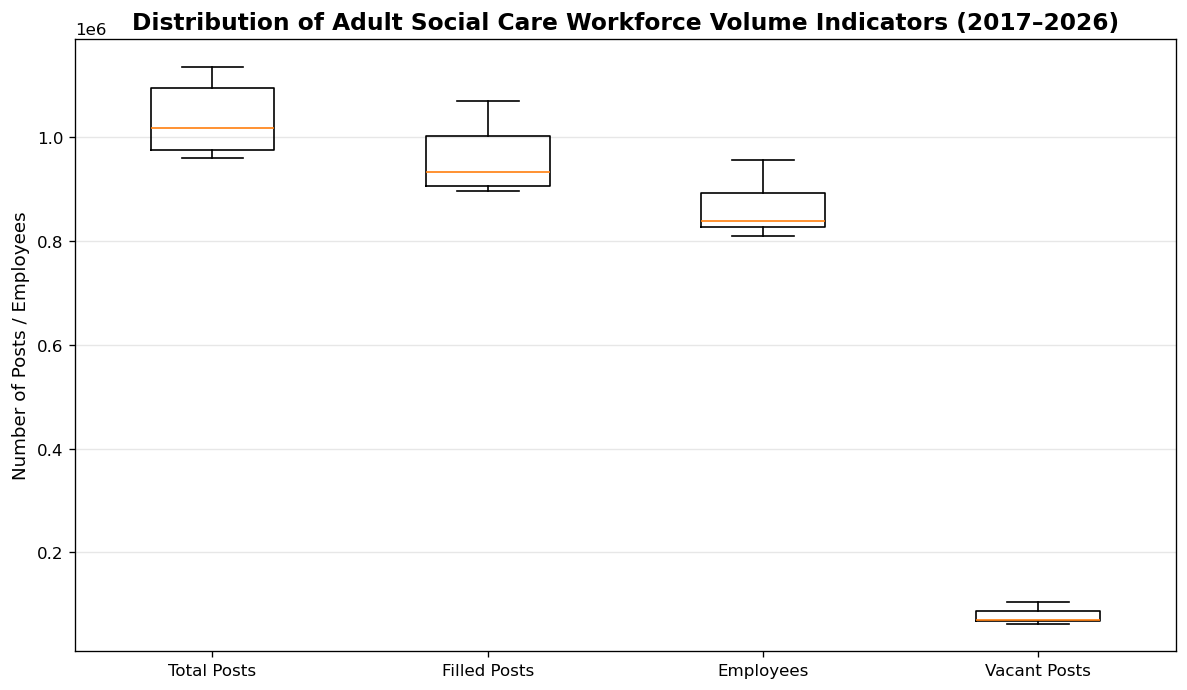

In [9]:
# Workforce volume indicators
volume_vars = [
    'Tot_Posts',
    'Filled_Posts',
    'Employees',
    'Vacant_Posts'
]

volume_labels = [
    'Total Posts',
    'Filled Posts',
    'Employees',
    'Vacant Posts'
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [sfc[var].dropna() for var in volume_vars],
    tick_labels=volume_labels
)

plt.title(
    'Distribution of Adult Social Care Workforce Volume Indicators (2017–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Number of Posts / Employees', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../04_Output/Figures/Workforce_Volume_Boxplot.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Interpretation:**  
The boxplots show the distribution and variation of the main workforce volume indicators across 2017–2026, complementing the descriptive statistics presented in Table 4.1.

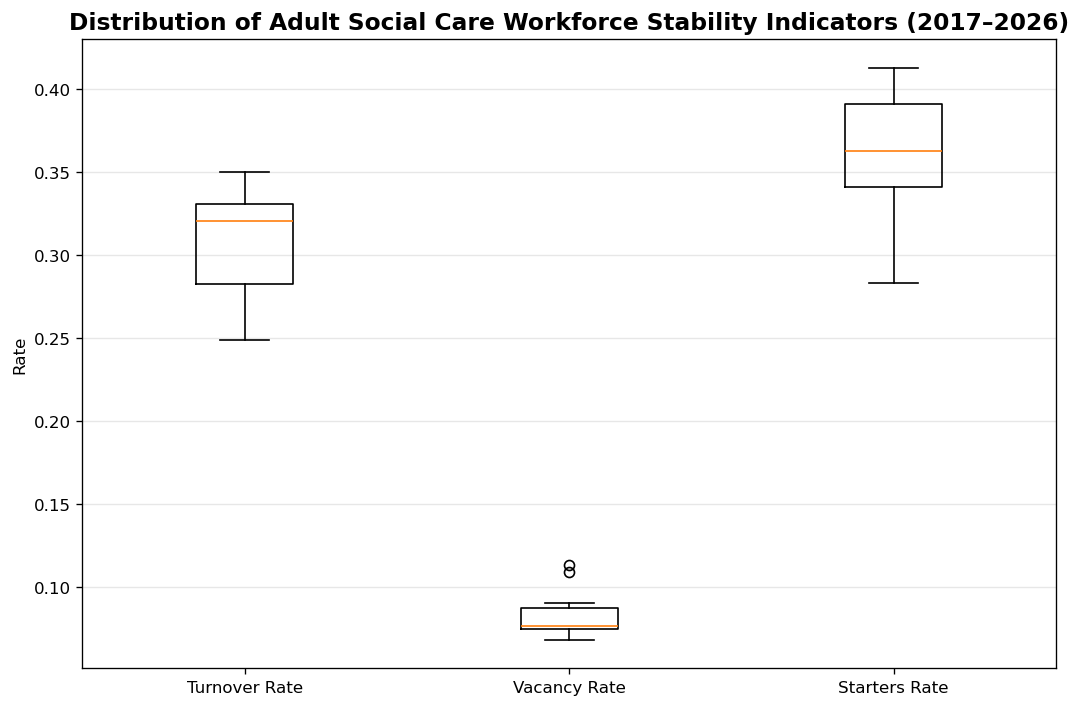

In [10]:
# Boxplot 2: Workforce Stability Rate Indicators

rate_vars = [
    'Turnover_Rt',
    'Vacancy_Rt',
    'Starters_Rt'
]

rate_labels = [
    'Turnover Rate',
    'Vacancy Rate',
    'Starters Rate'
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    [sfc[var].dropna() for var in rate_vars],
    tick_labels=rate_labels
)

plt.title(
    'Distribution of Adult Social Care Workforce Stability Indicators (2017–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Rate')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../04_Output/Figures/Workforce_Stability_Boxplot.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Interpretation:** The boxplot shows the distribution of turnover, vacancy, and starters rates between 2017 and 2026. Turnover and starters rates show greater variation, while the vacancy rate remains comparatively stable over the period.

## 4.2 Workforce Stability Trends

To compare changes in workforce stability over time, the vacancy rate, turnover rate, and starters rate are standardised using z-scores before visualisation. Standardisation removes differences in scale, allowing the variables to be compared on the same graph and making similarities or differences in their trends easier to interpret.

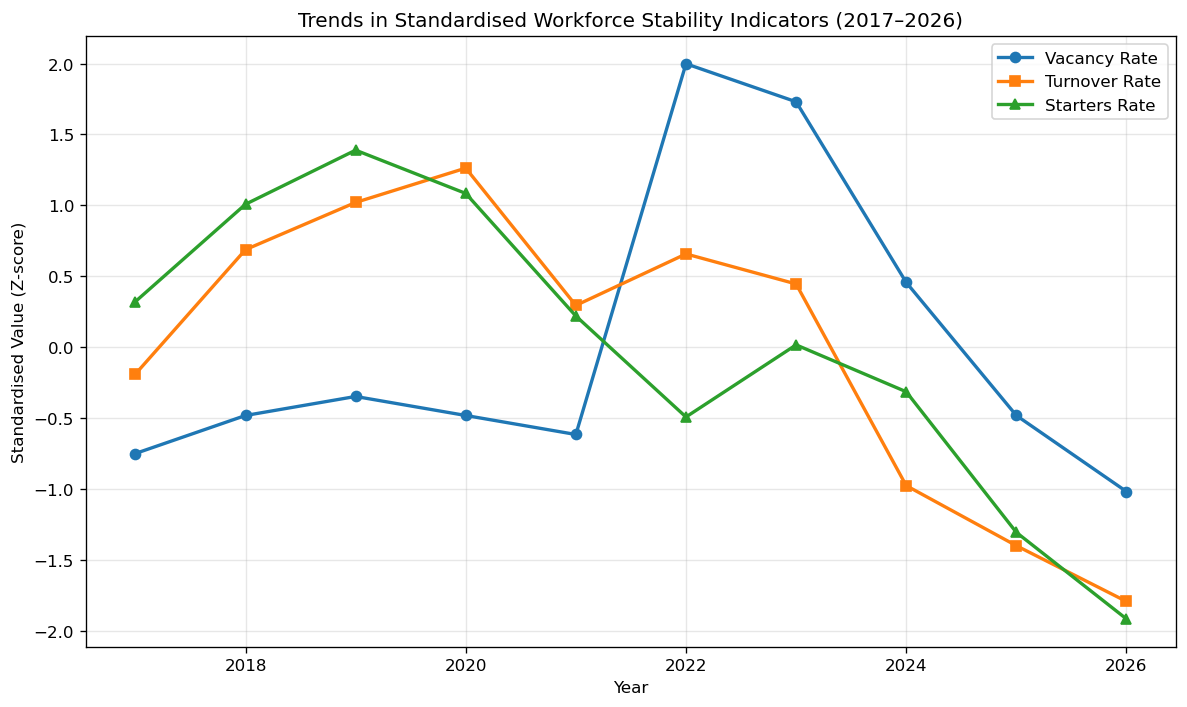

In [11]:
# Select variables
stability = sfc[['Year',
                 'Vacancy_Rt',
                 'Turnover_Rt',
                 'Starters_Rt']].copy()

# Standardise
scaler = StandardScaler()

stability[['Vacancy_Rt',
           'Turnover_Rt',
           'Starters_Rt']] = scaler.fit_transform(
    stability[['Vacancy_Rt',
               'Turnover_Rt',
               'Starters_Rt']]
)

# Plot
plt.figure(figsize=(10,6))

plt.plot(stability['Year'], stability['Vacancy_Rt'],
         marker='o', linewidth=2, label='Vacancy Rate')

plt.plot(stability['Year'], stability['Turnover_Rt'],
         marker='s', linewidth=2, label='Turnover Rate')

plt.plot(stability['Year'], stability['Starters_Rt'],
         marker='^', linewidth=2, label='Starters Rate')

plt.title('Trends in Standardised Workforce Stability Indicators (2017–2026)')
plt.xlabel('Year')
plt.ylabel('Standardised Value (Z-score)')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/Workforce_Stability_Trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation:
The standardised trends show that vacancy, turnover, and starter rates followed different patterns over the study period. Turnover and starter rates increased gradually between 2017 and 2020 before declining in later years, whereas vacancy rates remained relatively stable until 2021 before rising sharply in 2022 and then declining. These contrasting patterns suggest changes in workforce stability and recruitment dynamics within the adult social care sector over time.

## 4.3 Workforce Capacity Trends

The workforce capacity indicators are visualised to examine changes in staffing levels over time. Since these variables are measured in the same unit (number of posts or employees), they are plotted using their original values without standardisation.

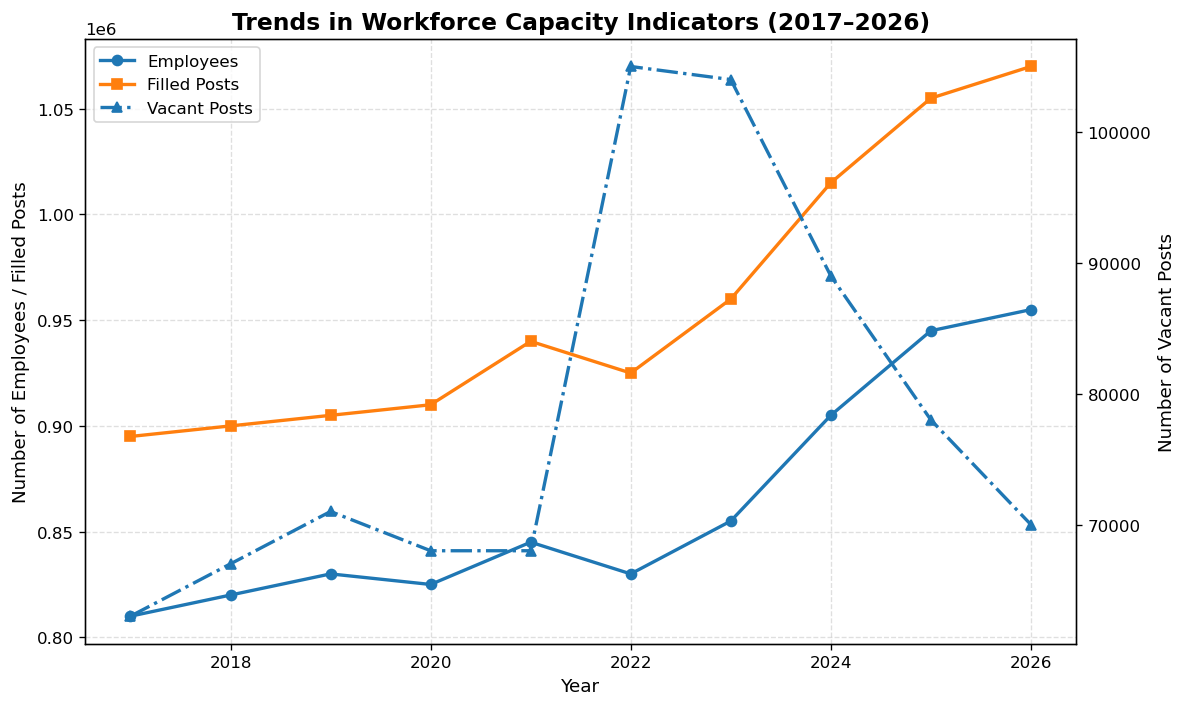

In [12]:
# Select workforce capacity variables
capacity = sfc[['Year', 'Employees', 'Filled_Posts', 'Vacant_Posts']].copy()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Employees
line1 = ax1.plot(
    capacity['Year'],
    capacity['Employees'],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Employees'
)

# Filled Posts
line2 = ax1.plot(
    capacity['Year'],
    capacity['Filled_Posts'],
    marker='s',
    linewidth=2,
    markersize=6,
    label='Filled Posts'
)

# Primary axis formatting
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Employees / Filled Posts', fontsize=11)
ax1.tick_params(axis='y')
ax1.grid(True, linestyle='--', alpha=0.4)

# Secondary axis for Vacant Posts
ax2 = ax1.twinx()

line3 = ax2.plot(
    capacity['Year'],
    capacity['Vacant_Posts'],
    marker='^',
    linestyle='-.',
    linewidth=2,
    markersize=6,
    label='Vacant Posts'
)

ax2.set_ylabel('Number of Vacant Posts', fontsize=11)
ax2.tick_params(axis='y')

# Combine legends
lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc='upper left',
    frameon=True,
    fontsize=10
)

# Title
plt.title(
    'Trends in Workforce Capacity Indicators (2017–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "../04_Output/Figures/Workforce_Capacity_Trends.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**:
The figure shows a general increase in both employees and filled posts between 2017 and 2026, indicating continued growth in the adult social care workforce over the study period. In contrast, vacant posts remained relatively stable until 2021 before increasing sharply in 2022 and subsequently declining. Despite this improvement, vacancies remained above pre-2022 levels, suggesting that workforce shortages persisted even as the number of employees and filled posts increased.

## Summary: 
The Skills for Care data provide an overview of workforce size, capacity, stability, and vacancies from 2017 to 2026. Descriptive statistics and visual analysis highlight variation across key workforce indicators and provide a foundation for subsequent analysis.

# Part II: Home Office Dataset

This section prepares and explores the Home Office Health and Care Worker visa dataset. The dataset provides quarterly information on Health and Care Worker visa grants and is explored to understand trends in international recruitment into the UK adult social care workforce.

## 1. Load the Dataset

The cleaned Home Office dataset is loaded into Python for inspection, descriptive analysis, and initial exploration.

In [13]:
# Load the Home Office dataset
ho = pd.read_excel("../02_Clean_Data/Home_Office/Home_Office_Cleaned_Dataset.xlsx")

# Preview the dataset
ho.head()

,Year,Year_Quarter,Quarter_No,Visa_Grants
0,2021,2021 Q1,Q1,26
1,2021,2021 Q2,Q2,3
2,2021,2021 Q2,Q2,16
3,2021,2021 Q2,Q2,226
4,2021,2021 Q2,Q2,1


**Interpretation**:
The preview confirms that the cleaned Home Office dataset has been successfully imported and is ready for analysis.

## 2. Dataset Inspection

The dataset is inspected to verify its structure, dimensions, variable types, and completeness before analysis. This ensures that the cleaned dataset is suitable for descriptive and exploratory analysis.

# 2.1: Dataset Preview

In [14]:
ho.head()

,Year,Year_Quarter,Quarter_No,Visa_Grants
0,2021,2021 Q1,Q1,26
1,2021,2021 Q2,Q2,3
2,2021,2021 Q2,Q2,16
3,2021,2021 Q2,Q2,226
4,2021,2021 Q2,Q2,1


# 2.2 Dataset Dimensions

In [15]:
print(f"Rows: {ho.shape[0]}")
print(f"Columns: {ho.shape[1]}")

Rows: 505
Columns: 4


**Interpretation**:
The dataset dimensions provide the number of observations and variables available for analysis.

# 2.3 Data Types and Completeness

In [16]:
ho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          505 non-null    int64 
 1   Year_Quarter  505 non-null    object
 2   Quarter_No    505 non-null    object
 3   Visa_Grants   505 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 15.9+ KB


**Interpretation**:
The output confirms the data types of each variable and provides an overview of the completeness of the dataset.

# 2.4 Missing Values

In [17]:
ho.isnull().sum()

Year            0
Year_Quarter    0
Quarter_No      0
Visa_Grants     0
dtype: int64

**Interpretation**:
The missing value summary identifies whether additional preprocessing is required before analysis.

## 3. Descriptive Statistics

Descriptive statistics are generated to summarise the distribution of quarterly Health and Care Worker visa grants over the study period. This provides an overview of the central tendency, variability, and range of international recruitment before further exploratory analysis.

In [18]:
ho.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,505.0,2024.20,1.10,2021.0,2024.0,2025.0,2025.0,2026.0
Visa_Grants,505.0,318.69,2527.27,1.0,1.0,3.0,13.0,33122.0


In [19]:
ho_summary = ho.describe().T.round(2)

ho_summary.to_csv(
    "../04_Output/Tables/HomeOffice_Visa_Summary_Statistics.csv"
)
print("Home Office summary statistics exported.")

Home Office summary statistics exported.


**Interpretation**:
The descriptive statistics provide an overview of the quarterly distribution of Health and Care Worker visa grants, including the average number of visas issued, the variability across quarters, and the overall range observed during the study period.

# 4. Initial Exploratory Analysis

### 4.1 Quarterly Visa Grant Trends

Quarterly Health and Care Worker visa grants are aggregated to produce a single observation for each quarter. This provides a clear view of changes in international recruitment over time and supports subsequent comparative and time-series analyses.

In [20]:
# Aggregate visa grants by quarter
visa_trend = (
    ho.groupby(['Year', 'Year_Quarter'], as_index=False)['Visa_Grants']
      .sum()
)

# Display the aggregated data
visa_trend.head()

,Year,Year_Quarter,Visa_Grants
0,2021,2021 Q1,26
1,2021,2021 Q2,246
2,2021,2021 Q3,811
3,2021,2021 Q4,2330
4,2022,2022 Q1,3967


**4.2 Quarterly Health and Care Worker Visa Grant Trends**

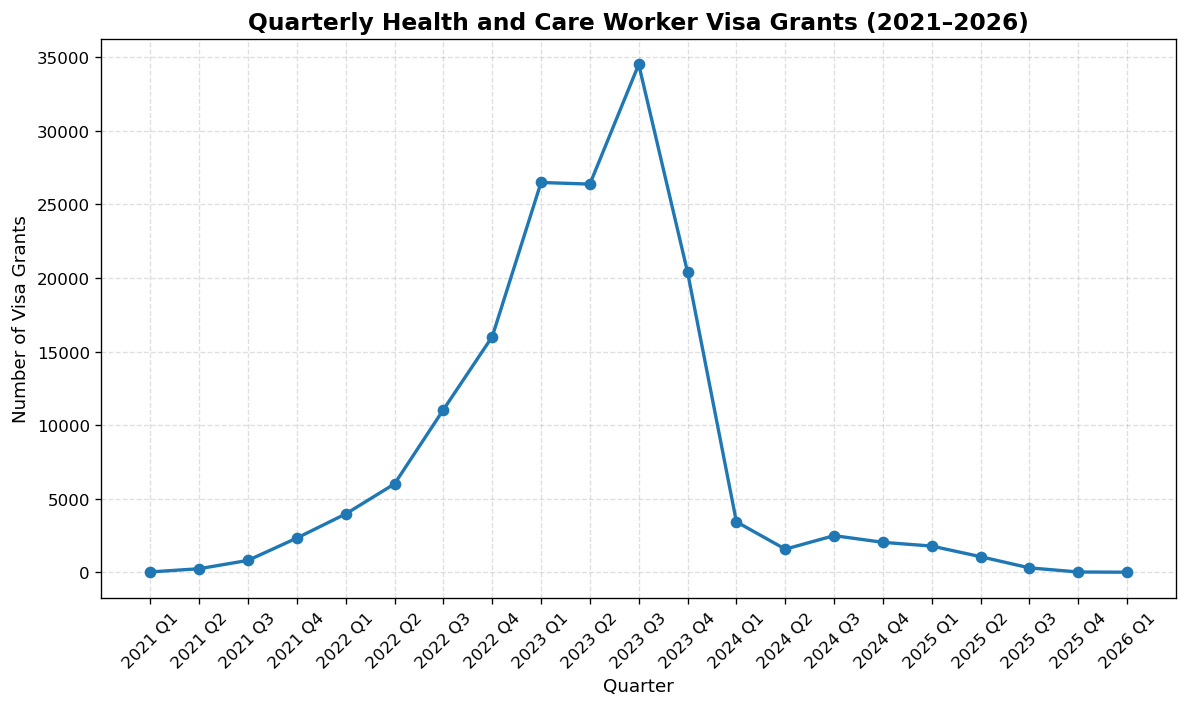

In [21]:
# Plot quarterly visa grants

plt.figure(figsize=(10,6))

plt.plot(
    visa_trend['Year_Quarter'],
    visa_trend['Visa_Grants'],
    marker='o',
    linewidth=2,
    markersize=6
)

plt.title('Quarterly Health and Care Worker Visa Grants (2021–2026)',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Number of Visa Grants', fontsize=11)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/Quarterly_Health_Care_Visa_Grants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation**:
The figure illustrates the quarterly trend in Health and Care Worker visa grants between 2021 and 2026. The trend highlights changes in international recruitment over time and provides an indication of how the use of overseas recruitment has evolved in response to workforce demand within the UK adult social care sector.

### 4.3 Annual Health and Care Worker Visa Grants

Quarterly visa grants are aggregated by year to examine annual changes in international recruitment. This provides a broader view of recruitment patterns over the study period and complements the quarterly trend analysis.

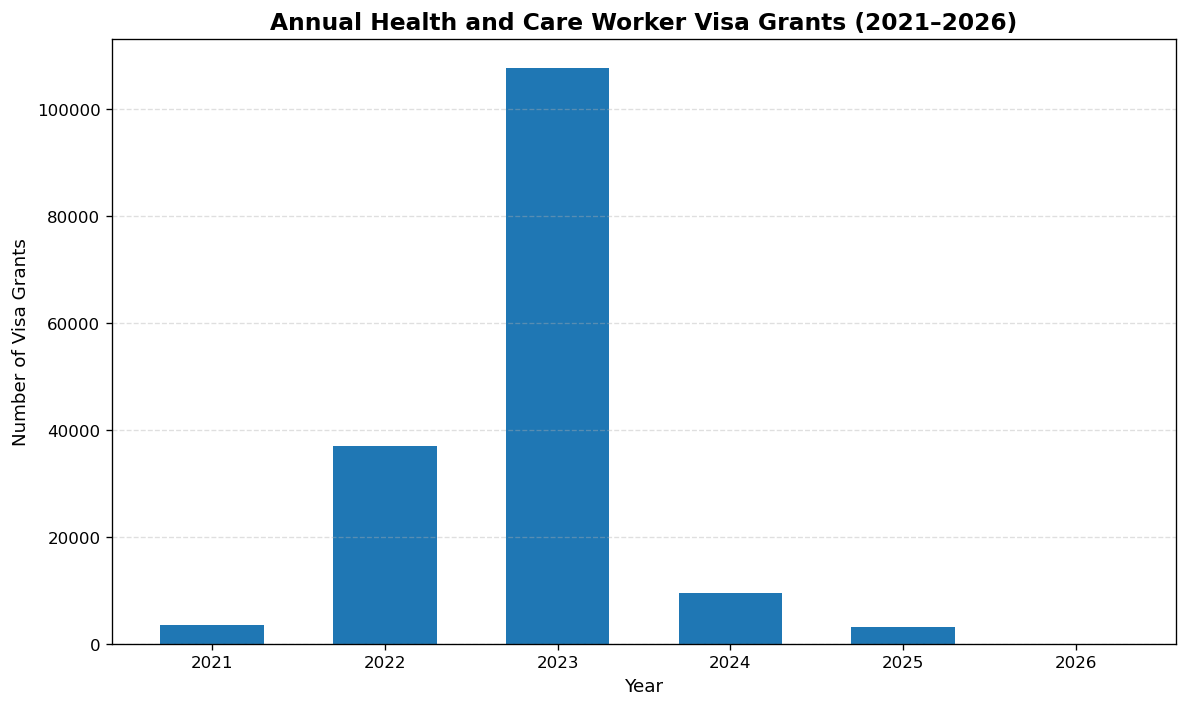

In [22]:
# Aggregate visa grants by year
annual_visa = (
    ho.groupby('Year', as_index=False)['Visa_Grants']
      .sum()
)

# Plot annual visa grants
plt.figure(figsize=(10, 6))

plt.bar(
    annual_visa['Year'].astype(str),
    annual_visa['Visa_Grants'],
    width=0.6
)

plt.title(
    'Annual Health and Care Worker Visa Grants (2021–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Number of Visa Grants', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/Annual_Health_Care_Visa_Grants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation**:
The annual totals provide a broader view of changes in Health and Care Worker visa grants over the study period. Comparing annual totals makes it easier to identify periods of increasing or decreasing international recruitment and complements the quarterly trends presented in the previous figure.

## 5. Summary

This section explored the Home Office Health and Care Worker visa dataset through data inspection, descriptive statistics, and trend analysis. Quarterly and annual visualisations provided an overview of changes in international recruitment between 2021 and 2026. The cleaned dataset will be used in subsequent comparative and cross-correlation analyses to examine its relationship with workforce indicators and migrant employment trends.

# Part III: Office for National Statistics (ONS) Dataset

This section prepares and explores the Office for National Statistics (ONS) dataset, which provides quarterly information on employment levels and employment rates by country of birth. The dataset is analysed to understand trends in migrant employment and establish the foundation for subsequent time-series forecasting.

## 1. Load the Dataset

The cleaned ONS dataset is loaded into Python for inspection, descriptive analysis, and exploratory analysis.

In [23]:
# Load the ONS dataset
ons = pd.read_excel("../02_Clean_Data/ONS/Cleaned_ONS_Country_Of_Birth_Datatset.xlsx")

# Preview the dataset
ons.head()

,Quarter,Year,Quarter_No,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt
0,Jan-Mar 1997,1997,Q1,26245,24323,1921,638,1283,70.401265,71.263537,61.062884,64.742004,59.408774
1,Apr-Jun 1997,1997,Q2,26444,24468,1975,652,1323,70.825526,71.666639,61.859625,66.614214,59.776514
2,Jul-Sep 1997,1997,Q3,26707,24715,1991,656,1335,71.443139,72.299920,62.324432,68.028845,59.884962
3,Oct-Dec 1997,1997,Q4,26695,24681,2013,660,1353,71.358964,72.215712,62.320050,66.812424,60.364692
4,Jan-Mar 1998,1998,Q1,26546,24505,2041,680,1360,70.933513,71.758337,62.370360,66.424527,60.545483


**Interpretation**:
The preview confirms that the cleaned ONS dataset has been successfully imported and is ready for analysis.

# 1.1 Create a quarterly Date variable

In [24]:
ons = pd.read_excel("../02_Clean_Data/ONS/Cleaned_ONS_Country_Of_Birth_Datatset.xlsx")

# Create a quarterly Date variable
quarter_month = {
    'Q1': 1,
    'Q2': 4,
    'Q3': 7,
    'Q4': 10
}

ons['Date'] = pd.to_datetime({
    'year': ons['Year'],
    'month': ons['Quarter_No'].map(quarter_month),
    'day': 1
})

ons.head()

,Quarter,Year,Quarter_No,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt,Date
0,Jan-Mar 1997,1997,Q1,26245,24323,1921,638,1283,70.401265,71.263537,61.062884,64.742004,59.408774,1997-01-01
1,Apr-Jun 1997,1997,Q2,26444,24468,1975,652,1323,70.825526,71.666639,61.859625,66.614214,59.776514,1997-04-01
2,Jul-Sep 1997,1997,Q3,26707,24715,1991,656,1335,71.443139,72.299920,62.324432,68.028845,59.884962,1997-07-01
3,Oct-Dec 1997,1997,Q4,26695,24681,2013,660,1353,71.358964,72.215712,62.320050,66.812424,60.364692,1997-10-01
4,Jan-Mar 1998,1998,Q1,26546,24505,2041,680,1360,70.933513,71.758337,62.370360,66.424527,60.545483,1998-01-01


**Interpretation**:
The dataset was successfully imported, and a quarterly date variable was created. This variable provides a continuous time index that will be used consistently throughout the exploratory analysis, cross-correlation analysis, and time-series forecasting.

# 2. Dataset Inspection

# 2.1 Dataset Preview

In [25]:
ons.head()

,Quarter,Year,Quarter_No,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt,Date
0,Jan-Mar 1997,1997,Q1,26245,24323,1921,638,1283,70.401265,71.263537,61.062884,64.742004,59.408774,1997-01-01
1,Apr-Jun 1997,1997,Q2,26444,24468,1975,652,1323,70.825526,71.666639,61.859625,66.614214,59.776514,1997-04-01
2,Jul-Sep 1997,1997,Q3,26707,24715,1991,656,1335,71.443139,72.299920,62.324432,68.028845,59.884962,1997-07-01
3,Oct-Dec 1997,1997,Q4,26695,24681,2013,660,1353,71.358964,72.215712,62.320050,66.812424,60.364692,1997-10-01
4,Jan-Mar 1998,1998,Q1,26546,24505,2041,680,1360,70.933513,71.758337,62.370360,66.424527,60.545483,1998-01-01


# 2.2 Dataset Dimensions

In [26]:
print(f"Rows: {ons.shape[0]}")
print(f"Columns: {ons.shape[1]}")

Rows: 117
Columns: 14


**Interpretation**:
The dataset contains 117 quarterly observations and the variables required for analysing employment trends by country of birth.

# 2.3 Data Types and Completeness

In [27]:
ons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Quarter         117 non-null    object        
 1   Year            117 non-null    int64         
 2   Quarter_No      117 non-null    object        
 3   Tot_Emp         117 non-null    int64         
 4   UK_Born_Emp     117 non-null    int64         
 5   NonUK_Born_Emp  117 non-null    int64         
 6   EU27_Emp        117 non-null    int64         
 7   NonEU_Emp       117 non-null    int64         
 8   Tot_Emp_Rt      117 non-null    float64       
 9   UK_Emp_Rt       117 non-null    float64       
 10  NonUK_Emp_Rt    117 non-null    float64       
 11  EU27_Emp_Rt     117 non-null    float64       
 12  NonEU_Emp_Rt    117 non-null    float64       
 13  Date            117 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(6), object(2)
memo

**Interpretation**:
The dataset contains appropriate numeric and date variables with no inconsistencies in data types, making it suitable for time-series analysis.

# 2.4 Missing Values

In [28]:
ons.isnull().sum()

Quarter           0
Year              0
Quarter_No        0
Tot_Emp           0
UK_Born_Emp       0
NonUK_Born_Emp    0
EU27_Emp          0
NonEU_Emp         0
Tot_Emp_Rt        0
UK_Emp_Rt         0
NonUK_Emp_Rt      0
EU27_Emp_Rt       0
NonEU_Emp_Rt      0
Date              0
dtype: int64

**Interpretation**:
No missing values were identified, indicating that the dataset is complete and ready for exploratory and forecasting analyses.

## 3. Descriptive Statistics

Descriptive statistics are generated to summarise the distribution of employment levels and employment rates by country of birth. This provides an overview of the key characteristics of migrant employment before further exploratory and time-series analysis.

In [29]:
ons.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Year,117.0,2011.128205,1997.0,2004.0,2011.0,2018.0,2026.0,8.480747
Tot_Emp,117.0,30217.153846,26245.0,28407.0,29596.0,32321.0,34369.0,2255.4566
UK_Born_Emp,117.0,25947.102564,24323.0,25411.0,25873.0,26656.0,27273.0,721.880248
NonUK_Born_Emp,117.0,4264.299145,1921.0,2684.0,4131.0,5613.0,7698.0,1618.837366
EU27_Emp,117.0,1528.735043,638.0,771.0,1513.0,2232.0,2553.0,656.108832
NonEU_Emp,117.0,2735.649573,1283.0,1913.0,2654.0,3259.0,5298.0,1006.68091
Tot_Emp_Rt,117.0,73.143218,69.963552,71.949771,72.87516,74.867002,76.512777,1.686172
UK_Emp_Rt,117.0,73.7195,70.713164,72.873346,73.77452,74.710381,76.78676,1.435532
NonUK_Emp_Rt,117.0,68.865135,61.062884,64.447068,67.648992,74.177143,77.310533,4.915664
EU27_Emp_Rt,117.0,76.064476,64.742004,71.229276,76.884179,80.576995,83.268144,5.277641


In [30]:
ons_summary = ons.describe().T.round(2)

ons_summary.to_csv(
    "../04_Output/Tables/ONS_Summary_Statistics.csv"
)

print("ONS summary statistics exported.")

ONS summary statistics exported.


**Interpretation**:
The descriptive statistics provide an overview of the employment variables, including their central tendency, variability, and range over the study period.

# 4. Initial Exploratory Analysis

### 4.1 Quarterly Trends in Employment Levels by Country of Birth

Employment levels are standardised using z-scores to enable meaningful comparison between population groups with different employment magnitudes. Standardisation allows the analysis to focus on changes in employment patterns over time rather than differences in absolute values.

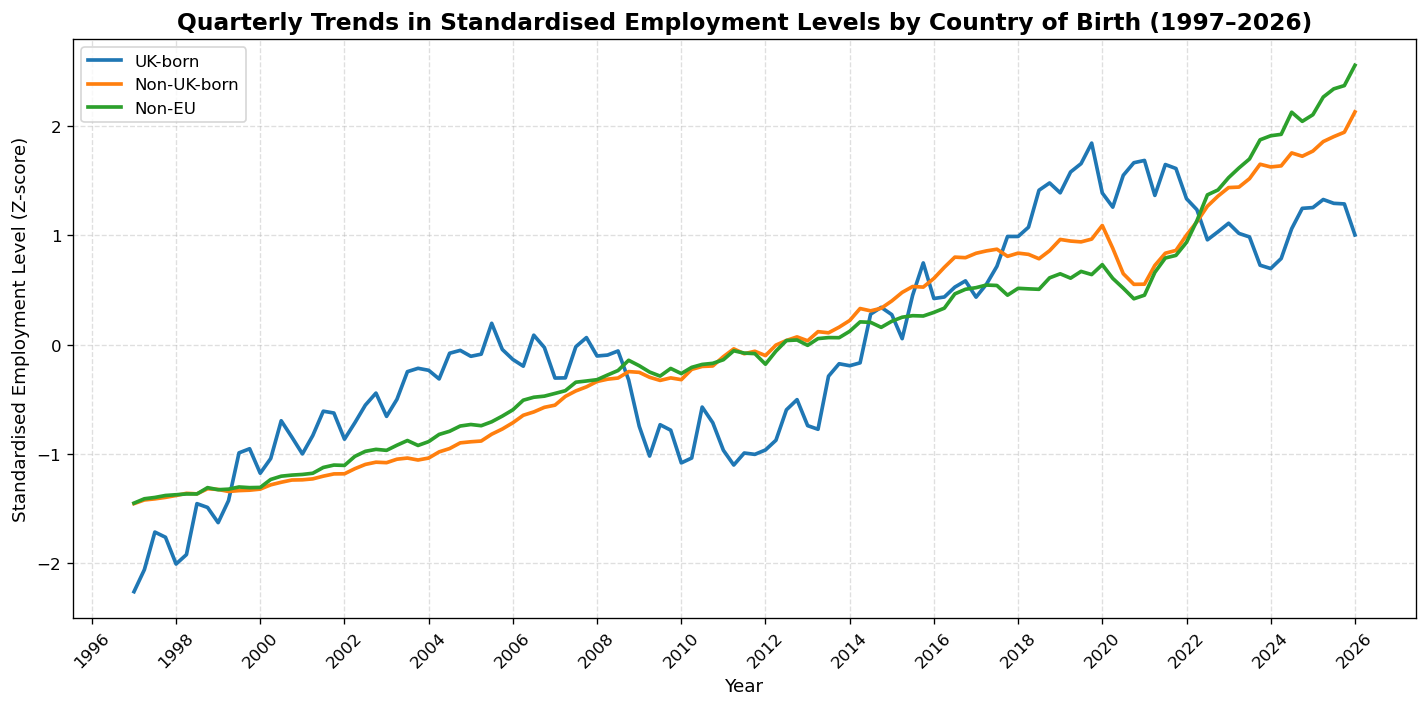

In [31]:
# Select employment level variables
employment = ons[['Date',
                  'UK_Born_Emp',
                  'NonUK_Born_Emp',
                  'NonEU_Emp']].copy()

# Standardise employment variables
scaler = StandardScaler()

employment[['UK_Born_Emp',
            'NonUK_Born_Emp',
            'NonEU_Emp']] = scaler.fit_transform(
    employment[['UK_Born_Emp',
                'NonUK_Born_Emp',
                'NonEU_Emp']]
)

# Create the figure
plt.figure(figsize=(12,6))

# Plot employment trends
plt.plot(
    employment['Date'],
    employment['UK_Born_Emp'],
    linewidth=2.2,
    label='UK-born'
)

plt.plot(
    employment['Date'],
    employment['NonUK_Born_Emp'],
    linewidth=2.2,
    label='Non-UK-born'
)

plt.plot(
    employment['Date'],
    employment['NonEU_Emp'],
    linewidth=2.2,
    label='Non-EU'
)

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Titles and labels
plt.title(
    'Quarterly Trends in Standardised Employment Levels by Country of Birth (1997–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Standardised Employment Level (Z-score)', fontsize=11)

plt.xticks(rotation=45)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/ONS_Employment_Levels_By_Country_of_Birth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**:
The figure compares quarterly employment trends among UK-born, non-UK-born, and non-EU populations after standardisation. Employment increased across all three groups over the study period, although the growth patterns differed. Non-UK-born and non-EU employment exhibited stronger and more sustained growth from around 2021 onwards, while UK-born employment showed greater fluctuations. Standardisation enables these trends to be compared directly despite differences in the original employment levels.

### 4.2 Quarterly Trends in Employment Rates by Country of Birth

Employment rates are standardised using z-scores to compare changes in labour market participation across population groups. Standardisation removes differences in scale and highlights similarities and differences in employment rate trends over time.

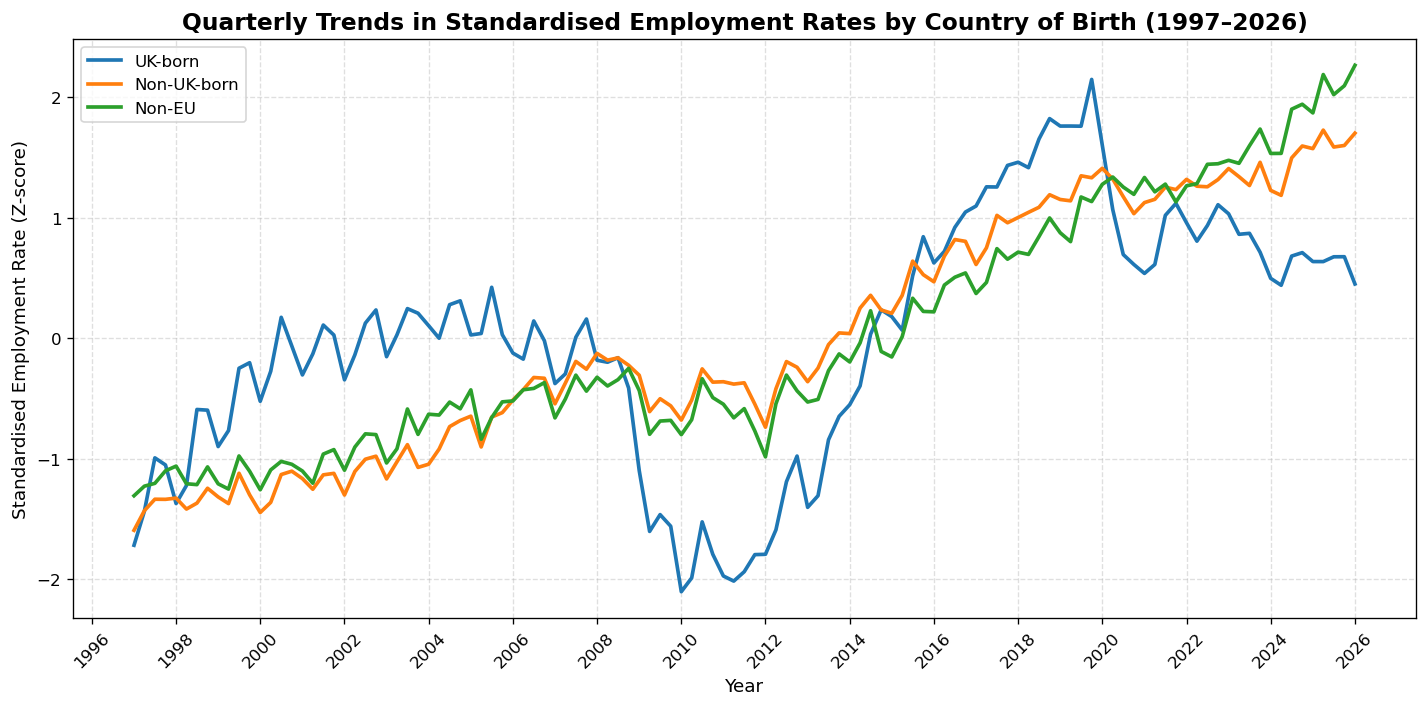

In [32]:
# Select employment rate variables
employment_rate = ons[['Date',
                       'UK_Emp_Rt',
                       'NonUK_Emp_Rt',
                       'NonEU_Emp_Rt']].copy()

# Standardise employment rates
scaler = StandardScaler()

employment_rate[['UK_Emp_Rt',
                 'NonUK_Emp_Rt',
                 'NonEU_Emp_Rt']] = scaler.fit_transform(
    employment_rate[['UK_Emp_Rt',
                     'NonUK_Emp_Rt',
                     'NonEU_Emp_Rt']]
)

# Create the figure
plt.figure(figsize=(12,6))

# Plot employment rates
plt.plot(
    employment_rate['Date'],
    employment_rate['UK_Emp_Rt'],
    linewidth=2.2,
    label='UK-born'
)

plt.plot(
    employment_rate['Date'],
    employment_rate['NonUK_Emp_Rt'],
    linewidth=2.2,
    label='Non-UK-born'
)

plt.plot(
    employment_rate['Date'],
    employment_rate['NonEU_Emp_Rt'],
    linewidth=2.2,
    label='Non-EU'
)

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Titles and labels
plt.title(
    'Quarterly Trends in Standardised Employment Rates by Country of Birth (1997–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Standardised Employment Rate (Z-score)', fontsize=11)

plt.xticks(rotation=45)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/ONS_Employment_Rates_By_Country_of_Birth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation**:
The figure compares quarterly employment rate trends among UK-born, non-UK-born, and non-EU populations after standardisation. Employment rates remained relatively stable over the study period, although differences in long-term trends are evident. Comparing the standardised series highlights periods where employment rates converged or diverged, providing insight into changes in labour market participation across population groups.

### 4.3 Quarterly Total Employment Trend

The overall trend in total UK employment is examined using the original employment values. Unlike the previous figures, standardisation is not applied because the objective is to illustrate the actual growth in total employment over time. This provides the broader labour market context for interpreting changes in migrant employment.

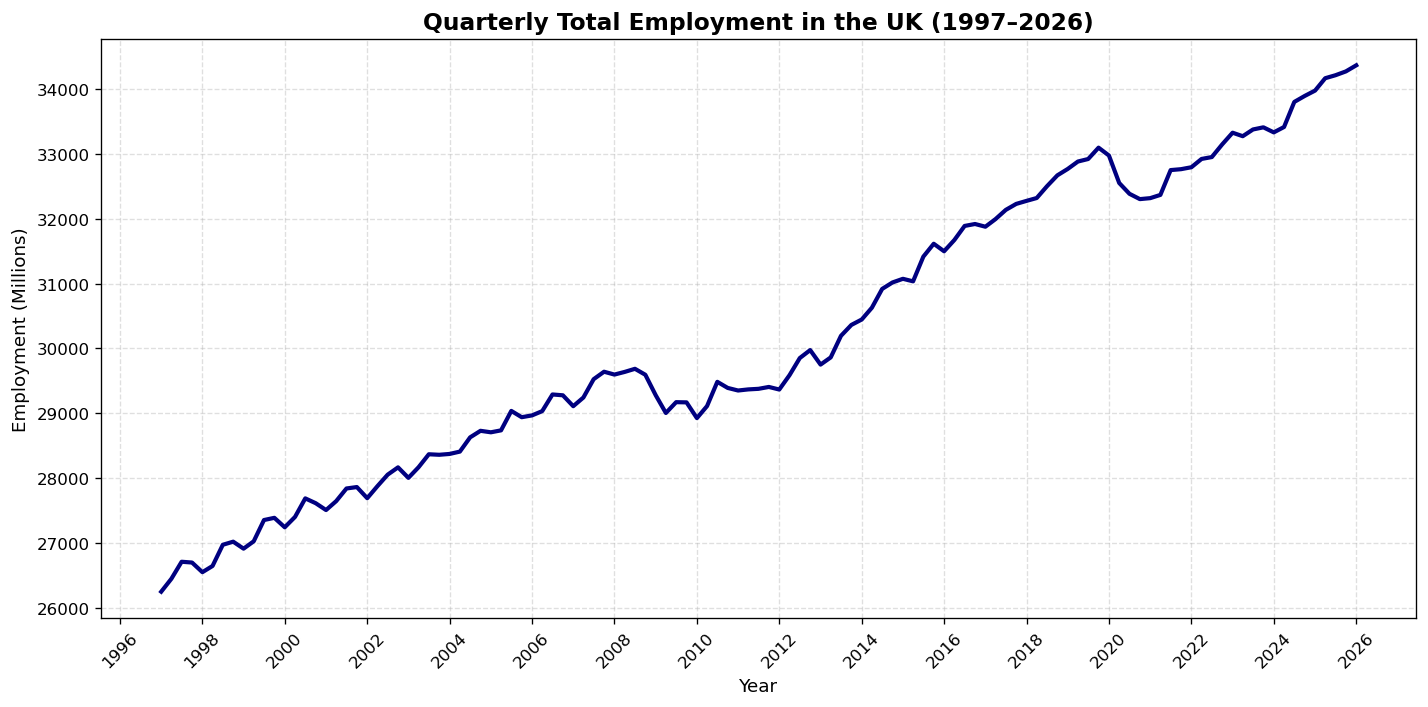

In [33]:
# Create the figure
plt.figure(figsize=(12,6))

# Plot total employment
plt.plot(
    ons['Date'],
    ons['Tot_Emp'],
    linewidth=2.5,
    color='navy'
)

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Titles and labels
plt.title(
    'Quarterly Total Employment in the UK (1997–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Employment (Millions)', fontsize=11)

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../04_Output/Figures/ONS_Total_Employment_Trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**:
The figure shows the overall trend in UK employment between 1997 and 2026. Total employment generally increased over the study period, although temporary declines are evident during periods of economic disruption. The long-term upward trend provides important context for interpreting changes in employment among UK-born and migrant populations and forms the basis for the forecasting analysis presented later in this study.

## 5. Summary

This section explored the ONS employment dataset through data inspection, descriptive statistics, and exploratory time-series visualisations. Standardised comparisons highlighted differences in employment levels and employment rates among UK-born, non-UK-born, and non-EU populations, while the total employment trend provided broader labour market context. These findings establish the foundation for the time-series forecasting analysis presented in a later notebook.